# DDM fit to value-capture pilot data (HSSM)

Fits a hierarchical Drift Diffusion Model to the singleton task.
Conditions: `absent`, `rank-0`, `rank-1`, `rank-2` (distractor value from low to high).

We compare:
- **Model 1 (v only)**: drift rate `v` varies by condition; `a`, `t` shared.
- **Model 2 (v + a)**: both `v` and `a` vary by condition; `t` shared.

Both models include per-subject random intercepts.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hssm
import arviz as az
from pathlib import Path

hssm.set_floatX('float32')  # recommended for JAX/numpyro backend

BIDS_DIR = Path('/data/ds-valuecapture')
subjects = [1, 2]
sessions = [1, 2]
CONDITION_ORDER = ['absent', 'rank-0', 'rank-1', 'rank-2']

Setting PyTensor floatX type to float32.
Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


## Load and prepare data

In [28]:
dfs = []
for sub in subjects:
    for ses in sessions:
        func_dir = BIDS_DIR / f'sub-{sub:02d}' / f'ses-{ses}' / 'func'
        for tsv in sorted(func_dir.glob(
                f'sub-{sub:02d}_ses-{ses}_task-valuecapture_run-*_events.tsv')):
            run = int(tsv.stem.split('run-')[1].split('_')[0])
            df = pd.read_csv(tsv, sep='\t')
            df['subject'] = sub
            df['session'] = ses
            df['run'] = run
            dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(dfs)} runs, {raw.subject.nunique()} subjects')

Loaded 32 runs, 2 subjects


In [29]:
# One row per trial (iti1 phase stores rt and correct)
trials = raw[raw['event_type'] == 'iti1'].copy()

def make_condition(row):
    if not row['distractor_present']:
        return 'absent'
    return f'rank-{int(row["value_rank"])}'

trials['condition'] = trials.apply(make_condition, axis=1)
trials['condition'] = pd.Categorical(
    trials['condition'], categories=CONDITION_ORDER, ordered=True)

# HSSM DDM expects:
#   rt       – response time in seconds (must be > 0)
#   response – 1 = upper boundary (correct), -1 = lower boundary (error)
data = trials[['subject', 'session', 'run', 'condition', 'rt', 'correct']].copy()
data = data.rename(columns={'correct': 'response'})

# Drop timeouts (no RT or no response recorded) before casting
data = data.dropna(subset=['rt', 'response'])
data = data[(data['rt'] > 0.1) & (data['rt'] < 3.0)]

# Recode: True/1 → 1 (upper), False/0 → -1 (lower)
data['response'] = data['response'].astype(int).map({1: 1, 0: -1})

# HSSM requires 'subj_idx' for hierarchical models
data['subj_idx'] = data['subject'].astype(str)

print(data.shape)
print(data['condition'].value_counts().sort_index())
print(data['response'].value_counts())
data.head()

(1259, 7)
condition
absent    318
rank-0    315
rank-1    310
rank-2    316
Name: count, dtype: int64
response
 1    1092
-1     167
Name: count, dtype: int64


,subject,session,run,condition,rt,response,subj_idx
41,1,1,1,rank-1,1.077517,1,1
52,1,1,1,rank-2,0.832696,-1,1
76,1,1,1,rank-0,0.736467,-1,1
87,1,1,1,absent,1.519242,1,1
98,1,1,1,rank-2,1.157781,1,1


## Quick EDA: RT distributions per condition

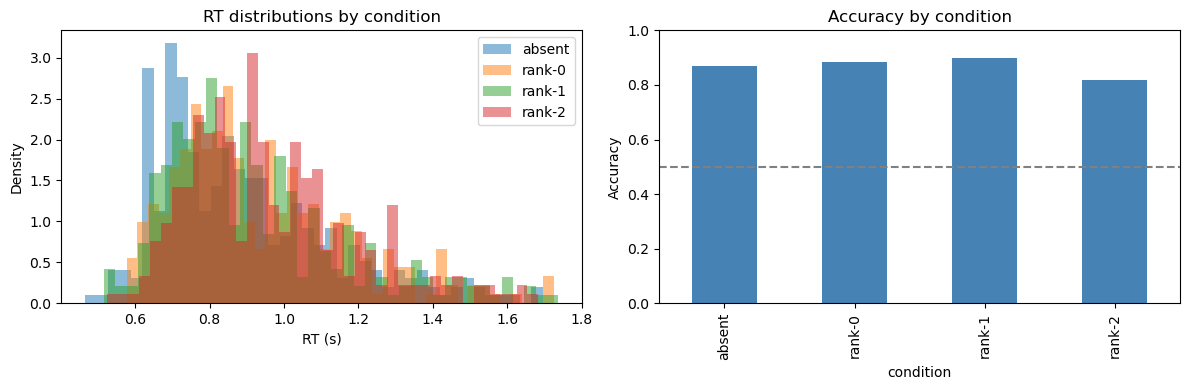

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cond, grp in data.groupby('condition', observed=True):
    axes[0].hist(grp['rt'], bins=40, alpha=0.5, label=cond, density=True)
axes[0].set_xlabel('RT (s)')
axes[0].set_ylabel('Density')
axes[0].set_title('RT distributions by condition')
axes[0].legend()

# response is -1/1; accuracy = proportion correct (==1)
acc = data.groupby('condition', observed=True)['response'].apply(lambda x: (x == 1).mean())
acc.plot.bar(ax=axes[1], color='steelblue')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy by condition')
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, ls='--', color='gray')

plt.tight_layout()
plt.show()

## Model 1: drift rate `v` varies by condition

Condition and subject as fixed effects on `v`; `a` and `t` shared.

(Random effects require many groups to estimate variance — with only 2 subjects, fixed effects are appropriate.)

In [31]:
model_v = hssm.HSSM(
    data=data,
    model='ddm',
    include=[
        {
            'name': 'v',
            'formula': 'v ~ 1 + C(condition, Treatment("absent")) + subj_idx',
        },
    ],
)
model_v

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1259

Parameters:

v:
    Formula: v ~ 1 + C(condition, Treatment("absent")) + subj_idx
    Priors:
        v_Intercept ~ Normal(mu: 2.0, sigma: 3.0)
        v_C(condition, Treatment("absent")) ~ Normal(mu: 0.0, sigma: 0.25)
        v_subj_idx ~ Normal(mu: 0.0, sigma: 0.25)
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

In [32]:
idata_v = model_v.sample(
    sampler='nuts_numpyro',
    chains=4,
    draws=1000,
    tune=2000,
    target_accept=0.95,
)

Using default initvals. 



/Users/gdehol/mambaforge/envs/value_capture_hssm/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:126: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

There were 3648 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
100%|██████████| 4000/4000 [00:01<00:00, 2744.32it/s]


/Users/gdehol/mambaforge/envs/value_capture_hssm/lib/python3.11/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['subj_idx'] have not been found and will be ignored
  warnings.warn(


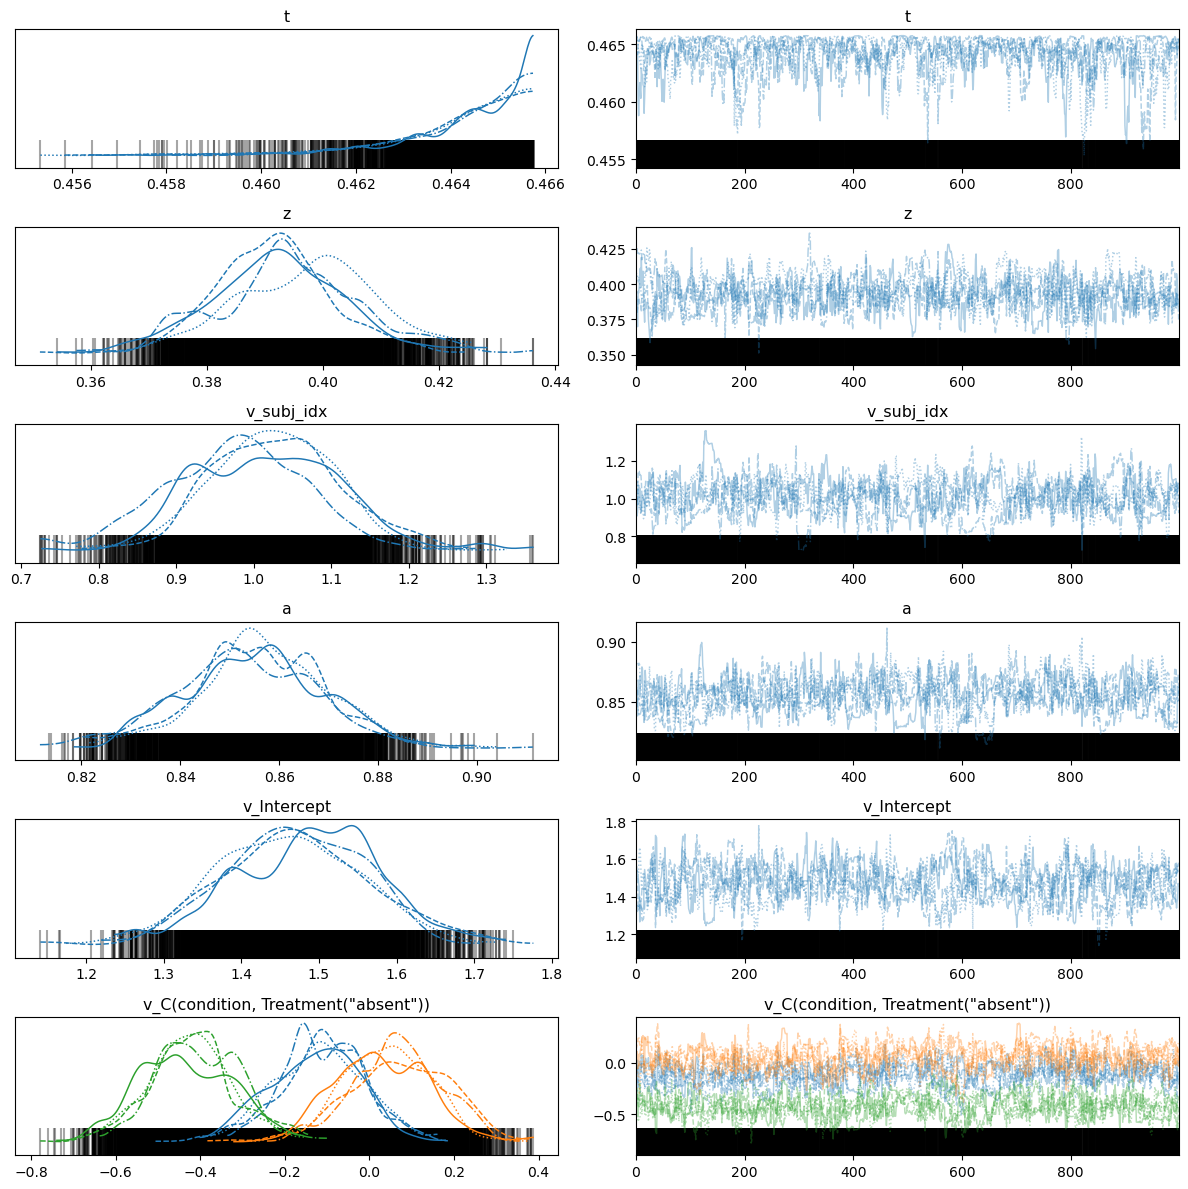

In [33]:
az.plot_trace(idata_v, var_names=['~subj_idx'], compact=True)
plt.tight_layout()
plt.show()

In [34]:
az.summary(idata_v, var_names=['~subj_idx'], round_to=3)

/Users/gdehol/mambaforge/envs/value_capture_hssm/lib/python3.11/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['subj_idx'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
t,0.464,0.001,0.461,0.466,0.000,0.000,272.550,455.308,1.007
z,0.394,0.012,0.372,0.416,0.001,0.000,274.360,404.328,1.023
v_subj_idx[2],1.013,0.089,0.858,1.191,0.008,0.004,125.290,227.700,1.051
a,0.855,0.014,0.829,0.880,0.001,0.000,253.686,327.270,1.012
v_Intercept,1.471,0.093,1.294,1.637,0.007,0.003,168.112,462.118,1.010
"v_C(condition, Treatment(""absent""))[rank-0]",-0.116,0.104,-0.316,0.077,0.009,0.004,153.528,333.326,1.018
"v_C(condition, Treatment(""absent""))[rank-1]",0.051,0.114,-0.152,0.265,0.010,0.004,123.149,355.835,1.030
"v_C(condition, Treatment(""absent""))[rank-2]",-0.421,0.105,-0.618,-0.219,0.009,0.004,141.693,364.204,1.014


## Model 2: both `v` and `a` vary by condition

In [35]:
model_va = hssm.HSSM(
    data=data,
    model='ddm',
    include=[
        {
            'name': 'v',
            'formula': 'v ~ 1 + C(condition, Treatment("absent")) + subj_idx',
        },
        {
            'name': 'a',
            'formula': 'a ~ 1 + C(condition, Treatment("absent")) + subj_idx',
        },
    ],
)
model_va

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1259

Parameters:

v:
    Formula: v ~ 1 + C(condition, Treatment("absent")) + subj_idx
    Priors:
        v_Intercept ~ Normal(mu: 2.0, sigma: 3.0)
        v_C(condition, Treatment("absent")) ~ Normal(mu: 0.0, sigma: 0.25)
        v_subj_idx ~ Normal(mu: 0.0, sigma: 0.25)
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1 + C(condition, Treatment("absent")) + subj_idx
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
        a_C(condition, Treatment("absent")) ~ Normal(mu: 0.0, sigma: 0.25)
        a_subj_idx ~ Normal(mu: 0.0, sigma: 0.25)
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

In [36]:
idata_va = model_va.sample(
    sampler='nuts_numpyro',
    chains=4,
    draws=1000,
    tune=2000,
    target_accept=0.95,
)

Using default initvals. 



/Users/gdehol/mambaforge/envs/value_capture_hssm/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:126: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

There were 3767 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
100%|██████████| 4000/4000 [00:01<00:00, 2615.82it/s]


/Users/gdehol/mambaforge/envs/value_capture_hssm/lib/python3.11/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['subj_idx'] have not been found and will be ignored
  warnings.warn(


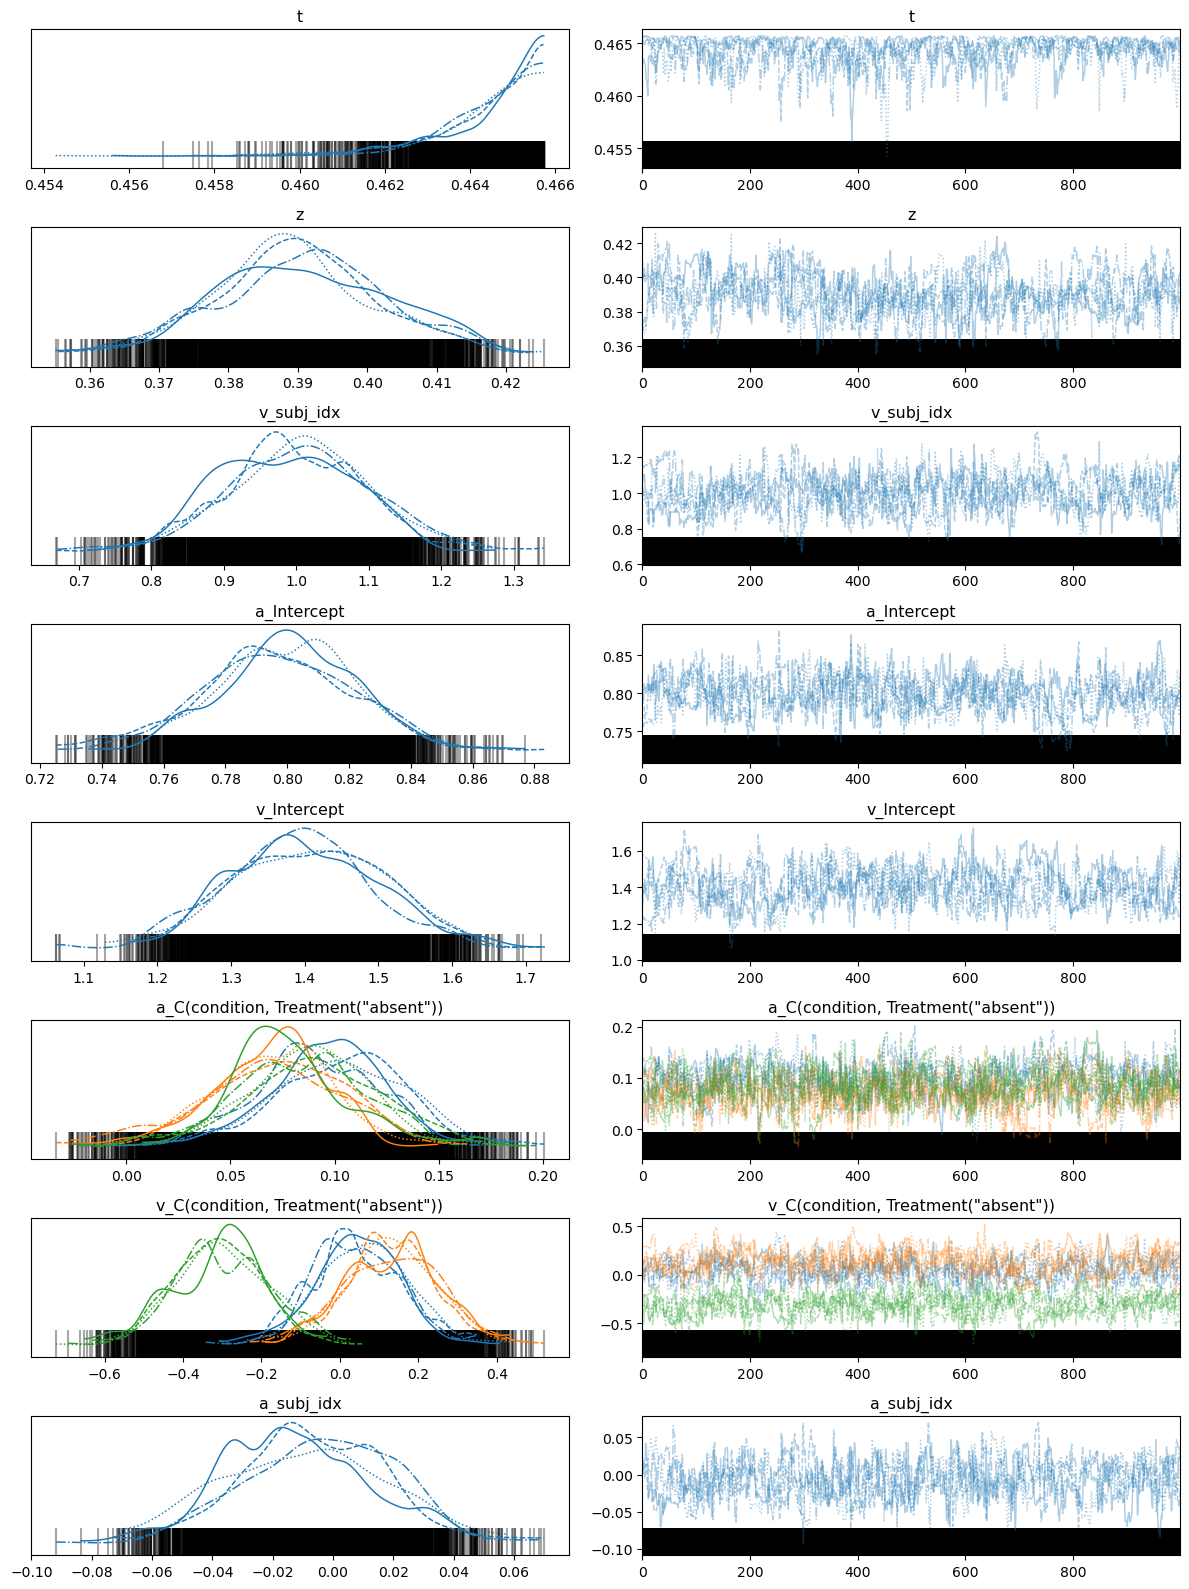

In [37]:
az.plot_trace(idata_va, var_names=['~subj_idx'], compact=True)
plt.tight_layout()
plt.show()

In [38]:
az.summary(idata_va, var_names=['~subj_idx'], round_to=3)

/Users/gdehol/mambaforge/envs/value_capture_hssm/lib/python3.11/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['subj_idx'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
t,0.464,0.001,0.462,0.466,0.000,0.000,298.358,770.001,1.017
z,0.390,0.012,0.371,0.415,0.001,0.000,183.404,378.638,1.017
v_subj_idx[2],0.999,0.098,0.817,1.178,0.007,0.004,173.829,448.098,1.013
a_Intercept,0.799,0.023,0.756,0.840,0.001,0.001,252.483,297.614,1.026
v_Intercept,1.402,0.099,1.220,1.589,0.007,0.004,191.847,326.993,1.025
"a_C(condition, Treatment(""absent""))[rank-0]",0.098,0.031,0.034,0.150,0.002,0.001,184.334,249.369,1.023
"a_C(condition, Treatment(""absent""))[rank-1]",0.071,0.031,0.011,0.128,0.002,0.001,269.334,341.024,1.017
"a_C(condition, Treatment(""absent""))[rank-2]",0.085,0.031,0.024,0.142,0.002,0.001,229.032,413.287,1.021
"v_C(condition, Treatment(""absent""))[rank-0]",0.048,0.112,-0.153,0.264,0.007,0.004,250.675,411.277,1.019
"v_C(condition, Treatment(""absent""))[rank-1]",0.132,0.118,-0.106,0.339,0.008,0.004,217.591,384.139,1.017


## Model comparison (WAIC / LOO)

In [39]:
comparison = az.compare(
    {'v_only': idata_v, 'v_and_a': idata_va},
    ic='loo',
    scale='log',
)
comparison

/Users/gdehol/mambaforge/envs/value_capture_hssm/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaforge/envs/value_capture_hssm/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
v_and_a,0,-410.439241,9.872299,0.000000,0.679297,40.301148,0.000000,True,log
v_only,1,-412.312276,6.651289,1.873036,0.320703,40.092977,3.184669,True,log


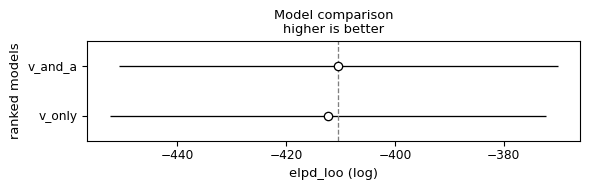

In [40]:
az.plot_compare(comparison, insample_dev=False)
plt.tight_layout()
plt.show()

## Posterior predictive check (winning model)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_46483/907781689.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  idata_thin = winning_idata.sel(draw=slice(None, None, winning_idata.posterior.dims['draw'] // 50))


AttributeError: 'NoneType' object has no attribute 'posterior_predictive'

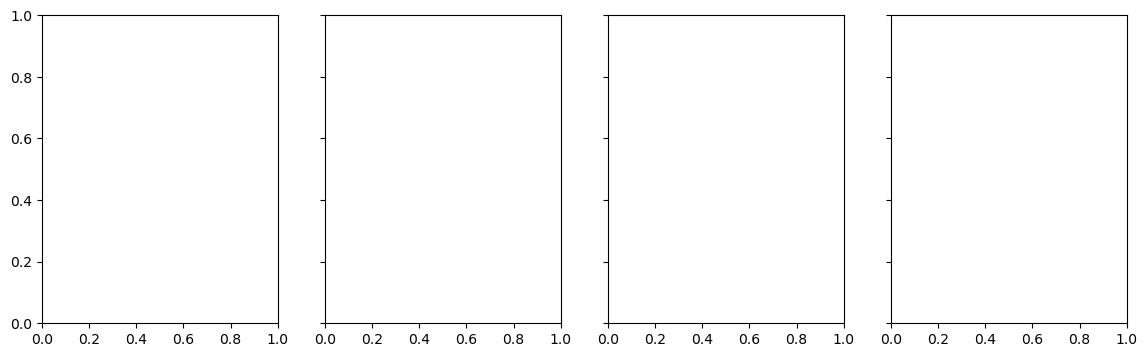

In [41]:
# Change to model_v / idata_v if that wins
winning_model = model_va
winning_idata = idata_va

# Subsample posterior to keep PPC fast (200 draws × 4 chains → 50 per chain)
idata_thin = winning_idata.sel(draw=slice(None, None, winning_idata.posterior.dims['draw'] // 50))

ppc = winning_model.sample_posterior_predictive(idata=idata_thin)

# Plot observed vs predicted RT quantiles per condition
quantiles = [0.1, 0.3, 0.5, 0.7, 0.9]
fig, axes = plt.subplots(1, len(CONDITION_ORDER), figsize=(14, 4), sharey=True)

# PPC RTs are signed: positive = correct (upper), negative = error (lower)
ppc_rt = ppc.posterior_predictive['rt'].values  # (chain, draw, obs)
ppc_rt_flat = ppc_rt.reshape(-1, ppc_rt.shape[-1])  # (samples, obs)

for ax, cond in zip(axes, CONDITION_ORDER):
    mask = (data['condition'] == cond).values

    obs_q = np.quantile(data.loc[mask & (data['response'] == 1), 'rt'], quantiles)
    pred_correct = ppc_rt_flat[:, mask]
    pred_correct = pred_correct[pred_correct > 0].reshape(-1)  # keep upper-boundary draws

    ax.fill_between(
        quantiles,
        np.quantile(pred_correct.reshape(ppc_rt_flat.shape[0], -1), 0.025, axis=0)
        if pred_correct.size > 0 else np.full(len(quantiles), np.nan),
        np.quantile(pred_correct.reshape(ppc_rt_flat.shape[0], -1), 0.975, axis=0)
        if pred_correct.size > 0 else np.full(len(quantiles), np.nan),
        alpha=0.3, label='95% CI',
    )
    ax.scatter(quantiles, obs_q, color='black', zorder=5, label='observed')
    ax.set_title(cond)
    ax.set_xlabel('Quantile')

axes[0].set_ylabel('RT (s)')
axes[0].legend(fontsize=8)
plt.suptitle('Posterior predictive: RT quantiles (correct trials)', y=1.02)
plt.tight_layout()
plt.show()

## Forest plot: condition effects on `v` (and `a`)

v params: ['v_Intercept', 'v_C(condition, Treatment("absent"))']
a params: ['a_Intercept', 'a_C(condition, Treatment("absent"))']


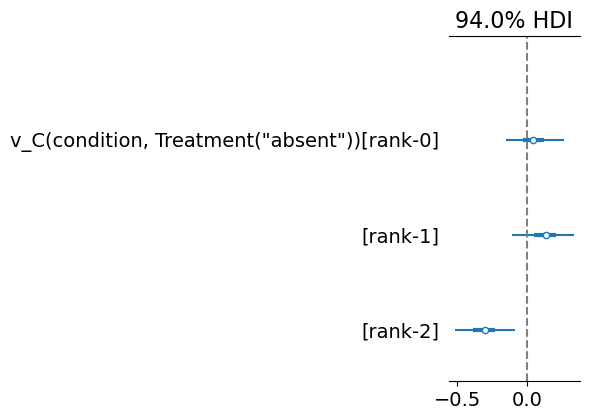

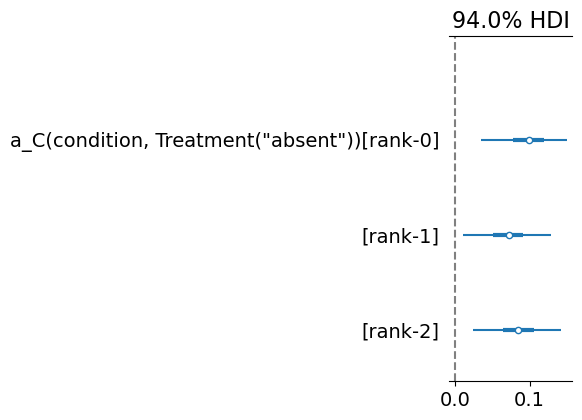

In [45]:
# Population-level (fixed) effects
pop_vars_v = [v for v in winning_idata.posterior.data_vars
              if v.startswith('v_') and 'subj_idx' not in v]
pop_vars_a = [v for v in winning_idata.posterior.data_vars
              if v.startswith('a_') and 'subj_idx' not in v]

print('v params:', pop_vars_v)
print('a params:', pop_vars_a)

az.plot_forest(
    winning_idata,
    var_names=pop_vars_v[1:],
    combined=True,
    hdi_prob=0.94,
)
plt.axvline(0, ls='--', color='gray')
plt.tight_layout()


az.plot_forest(
    winning_idata,
    var_names=pop_vars_a[1:],
    combined=True,
    hdi_prob=0.94,
)
plt.axvline(0, ls='--', color='gray')
plt.tight_layout()